## Manifold and silhouette demonstrations

In [6]:
import os
import re
import pandas as pd
import numpy as np
import qiime2
from qiime2 import Artifact
from qiime2.plugins import metadata, feature_table, diversity, emperor
from q2_emperor import plot, procrustes_plot, biplot, generic_plot
from scipy.spatial.distance import squareform, pdist
import skbio

In [7]:
!pwd

/ClusterApp/notebooks


In [8]:
def reformatTable(feat_table):
    """
    This Method Prepare The Meta And Feat Table To qiime2 and Return the pcoa object
    """
    last_attr = feat_table.columns[feat_table.columns.str.contains('ATTRIBUTE')][-1]
    plast_attr = feat_table.columns.get_loc(last_attr)+1
    meta = feat_table[feat_table.columns[:plast_attr]]
    meta.columns = meta.columns.str.replace('Filename', 'filename')
    meta.filename+' Peak area'
    meta.fillna('empty', inplace=True)
    meta = meta.astype(str)
    feat = feat_table[feat_table.columns[plast_attr:]].T
    feat.columns = meta.filename+' Peak area'
    feat_tmp = pd.DataFrame(feat.index)
    feat_tmp.reset_index(inplace=True)
    feat_tmp = pd.DataFrame(feat_tmp[0].apply(lambda a: a.split("_")[:2]).tolist())
    feat_tmp.reset_index(inplace=True)

    feat_tmp.columns = ['row ID', 'row m/z', 'row retention time']
    feat = pd.concat([feat_tmp, feat.reset_index(drop=True)], axis=1)
    return feat,meta

In [100]:
df = pd.read_csv('BAAT_Tissue_buckettable_quant_norm_noblank_utf8.csv')
df.head()

,filename,ATTRIBUTE_sample_name,ATTRIBUTE_sex,ATTRIBUTE_cage_id,ATTRIBUTE_tissue_type,ATTRIBUTE_female_parent,ATTRIBUTE_female_parent_genotype,ATTRIBUTE_genotype,ATTRIBUTE_male_parent,ATTRIBUTE_male_parent_genotype,...,10491_114.054967562357_3.53540694444444_N/A,10482_606.342068990071_5.39441944444444_N/A,10455_736.075174967447_4.81125925925925_N/A,10525_225.134237925211_9.3178_N/A,10531_114.054946899414_3.62348999999999_N/A,10513_735.573547363281_4.85172916666666_N/A,10501_113.070894877115_3.37563333333333_N/A,10507_198.185152053833_6.72989166666666_N/A,10523_225.13419342041_9.23704333333333_N/A,10515_186.98080698649_6.31061111111111_N/A
0,Baat126B.mzXML,Baat126B,male,F1,brain,baat7,het,ko,baat10,het,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Baat147B.mzXML,Baat147B,male,F5,brain,baat16,het,ko,baat12,het,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Baat150B.mzXML,Baat150B,female,F6,brain,baat16,het,ko,baat12,het,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Baat153B.mzXML,Baat153B,male,F7,brain,baat24,het,ko,baat19,het,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Baat163B.mzXML,Baat163B,male,G1,brain,baat57,het,ko,baat55,ko,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [101]:
feat,meta = reformatTable(df)

/tmp/ipykernel_919/443562344.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta.fillna('empty', inplace=True)


In [102]:
feat.head()

,row ID,row m/z,row retention time,Baat126B.mzXML Peak area,Baat147B.mzXML Peak area,Baat150B.mzXML Peak area,Baat153B.mzXML Peak area,Baat163B.mzXML Peak area,Baat164B.mzXML Peak area,Baat165B.mzXML Peak area,...,Baat175L.mzXML Peak area,Baat176L.mzXML Peak area,Baat180L.mzXML Peak area,Baat182L.mzXML Peak area,Baat185L.mzXML Peak area,Baat192L.mzXML Peak area,Baat196L.mzXML Peak area,Baat209L.mzXML Peak area,Baat214L.mzXML Peak area,Baat226L.mzXML Peak area
0,0,Sum,None,1.345797e+10,1.372968e+10,1.381407e+10,1.742756e+10,1.751231e+10,1.930629e+10,2.187738e+10,...,3.427931e+10,2.996657e+10,4.015010e+10,3.097883e+10,2.800318e+10,2.382556e+10,2.966428e+10,2.755934e+10,3.721942e+10,4.071728e+10
1,1,3,520.339179201244,9.439676e+07,5.553706e+07,6.729064e+07,1.047049e+08,1.506651e+08,1.720248e+08,1.697299e+08,...,4.861987e+09,4.100389e+09,5.501227e+09,4.186561e+09,3.837172e+09,3.522475e+09,3.626721e+09,4.006557e+09,4.981281e+09,6.535307e+09
2,2,9,522.354785965149,1.280483e+09,1.276552e+09,5.697207e+08,1.390494e+09,1.919721e+09,2.537259e+09,1.723269e+09,...,1.324559e+09,6.400071e+08,1.874499e+09,1.152737e+09,7.634998e+08,1.134557e+09,1.286463e+09,1.249567e+09,1.775772e+09,1.788032e+09
3,3,6,524.370473558075,1.993909e+08,2.515997e+08,4.186107e+08,6.788885e+07,1.425666e+08,2.391409e+08,1.018340e+08,...,6.022085e+08,5.171823e+08,9.829766e+08,7.136470e+08,1.783534e+08,7.609059e+08,7.601348e+08,6.393778e+08,7.901071e+08,1.500705e+09
4,4,8,568.338922038477,5.677433e+08,5.767513e+08,3.974152e+08,9.897962e+08,1.118205e+09,1.244174e+09,1.041600e+09,...,2.719725e+09,2.690502e+09,3.114993e+09,2.472893e+09,2.345338e+09,1.771978e+09,2.196505e+09,2.231869e+09,2.614448e+09,4.118269e+09


In [103]:
meta.head()

,filename,ATTRIBUTE_sample_name,ATTRIBUTE_sex,ATTRIBUTE_cage_id,ATTRIBUTE_tissue_type,ATTRIBUTE_female_parent,ATTRIBUTE_female_parent_genotype,ATTRIBUTE_genotype,ATTRIBUTE_male_parent,ATTRIBUTE_male_parent_genotype,ATTRIBUTE_plate number
0,Baat126B.mzXML,Baat126B,male,F1,brain,baat7,het,ko,baat10,het,2
1,Baat147B.mzXML,Baat147B,male,F5,brain,baat16,het,ko,baat12,het,2
2,Baat150B.mzXML,Baat150B,female,F6,brain,baat16,het,ko,baat12,het,2
3,Baat153B.mzXML,Baat153B,male,F7,brain,baat24,het,ko,baat19,het,1
4,Baat163B.mzXML,Baat163B,male,G1,brain,baat57,het,ko,baat55,ko,1


In [104]:
meta.shape

(248, 11)

In [105]:
def qiime2PCoA(sample_metadata, df, out_dir, metric, method='pcoa'):
    sample_metadata.rename(index=str, columns={"filename": "#SampleID"},
                           inplace=True)
    sample_metadata.columns = sample_metadata.columns.str.replace('\s', '_')

    sample_metadata.index = sample_metadata['#SampleID']
    sample_metadata.drop(['#SampleID'], axis=1, inplace=True)
    qsample_metadata = qiime2.metadata.Metadata(sample_metadata)

    df2 = df[df.columns[df.columns.str.contains(' Peak area')]]
    df2.columns = [re.sub('(.+\.mzX?ML) .+', '\\1', a) for a in df2.columns]
    df2.index = df['row ID'].astype(str)
    df2 = df2.T

    df2.fillna(0, inplace=True)
    zero_proportion = (df2 == 0).sum().sum() / df2.size

    if zero_proportion == 1.0: 
        raise ValueError(f"The DataFrame contains too many zero values ({zero_proportion:.2%}). Please check the input data table or try different scaling and normalization methods.")

    dm1 = squareform(pdist(df2, metric=metric))
    dm1 = skbio.DistanceMatrix(dm1, ids=df2.index.tolist())
    dm1 = Artifact.import_data("DistanceMatrix", dm1)
    if method=='pcoa':
        pcoa = diversity.methods.pcoa(dm1)
        emperor_plot = emperor.visualizers.plot(pcoa.pcoa, qsample_metadata)
    elif method=='tsne':
        tsne = diversity.methods.tsne(dm1, number_of_dimensions=3)
        emperor_plot = emperor.visualizers.plot(tsne.tsne, qsample_metadata)
    elif  method=='umap':
        umap = diversity.methods.umap(dm1, number_of_dimensions=3)
        emperor_plot = emperor.visualizers.plot(umap.umap, qsample_metadata)
    else:
        raise ValueError("method not found.")

    if '.qzv' in out_dir:
        emperor_plot.visualization.save(out_dir)
    else:
        emperor_plot.visualization.export_data(out_dir)
    return emperor_plot

In [25]:
pcoa_obj = qiime2PCoA(meta, feat,
                      out_dir=f'notebooks/teste_bat_canberra',
                      metric='canberra')

/tmp/ipykernel_919/1876302108.py:4: FutureWarning: The default value of regex will change from True to False in a future version.
  sample_metadata.columns = sample_metadata.columns.str.replace('\s', '_')
/opt/conda/envs/qiime2-2023.7/lib/python3.8/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:143: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -1782101.5739631453 and the largest is 102085331.51449636.
  warn(


In [55]:
tsne_obj = qiime2PCoA(meta, feat,
                      out_dir=f'notebooks/teste_bat_tsne2_canberra',
                      metric='canberra', method='tsne')

/tmp/ipykernel_919/1687486772.py:4: FutureWarning: The default value of regex will change from True to False in a future version.
  sample_metadata.columns = sample_metadata.columns.str.replace('\s', '_')
/opt/conda/envs/qiime2-2023.7/lib/python3.8/site-packages/q2_diversity/_ordination.py:72: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  proportion_explained=pd.Series(None, index=axis_labels),


In [106]:
umap_obj = qiime2PCoA(meta, feat,
                      out_dir=f'notebooks/teste_bat_umap_canberra',
                      metric='canberra', method='umap')

/tmp/ipykernel_919/155317105.py:4: FutureWarning: The default value of regex will change from True to False in a future version.
  sample_metadata.columns = sample_metadata.columns.str.replace('\s', '_')
/opt/conda/envs/qiime2-2023.7/lib/python3.8/site-packages/q2_diversity/_ordination.py:103: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  proportion_explained=pd.Series(None, index=axis_labels),


In [68]:
df2 = feat[feat.columns[feat.columns.str.contains(' Peak area')]]
df2.columns = [re.sub('(.+\.mzX?ML) .+', '\\1', a) for a in df2.columns]
df2.index = feat['row ID'].astype(str)
df2 = df2.T

df2.head()

row ID,0,1,2,3,4,5,6,7,8,9,...,10301,10302,10303,10304,10305,10306,10307,10308,10309,10310
Baat126B.mzXML,1.345797e+10,9.439676e+07,1.280483e+09,1.993909e+08,5.677433e+08,7.548975e+08,1.389334e+06,169217187.6,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Baat147B.mzXML,1.372968e+10,5.553706e+07,1.276552e+09,2.515997e+08,5.767513e+08,6.037413e+08,0.000000e+00,239755322.4,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Baat150B.mzXML,1.381407e+10,6.729064e+07,5.697207e+08,4.186107e+08,3.974152e+08,3.814192e+08,1.932423e+06,262268009.4,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Baat153B.mzXML,1.742756e+10,1.047049e+08,1.390494e+09,6.788885e+07,9.897962e+08,8.760252e+08,7.929538e+05,428730339.1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Baat163B.mzXML,1.751231e+10,1.506651e+08,1.919721e+09,1.425666e+08,1.118205e+09,1.038757e+09,1.034977e+06,369603996.3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [69]:
X_embedded = TSNE(n_components=2, init='random', perplexity=3, random_state=42).fit_transform(df2)

X_embedded.shape

(248, 2)

In [71]:
X_embedded[:5,:]

array([[ 25.964293, -53.903625],
       [ 33.272644, -51.695545],
       [ 16.629961, -57.36137 ],
       [-58.61641 , -20.889973],
       [-58.062946, -21.303534]], dtype=float32)

In [80]:
tdf = pd.DataFrame(X_embedded)
tdf.columns = ['t-SNE component 1', 't-SNE component 2']
tdf.head()

,t-SNE component 1,t-SNE component 2
0,25.964293,-53.903625
1,33.272644,-51.695545
2,16.629961,-57.361370
3,-58.616409,-20.889973
4,-58.062946,-21.303534


In [81]:
tdf['ATTRIBUTE_tissue_type'] = meta['ATTRIBUTE_tissue_type'].tolist()

<AxesSubplot: xlabel='t-SNE component 1', ylabel='t-SNE component 2'>

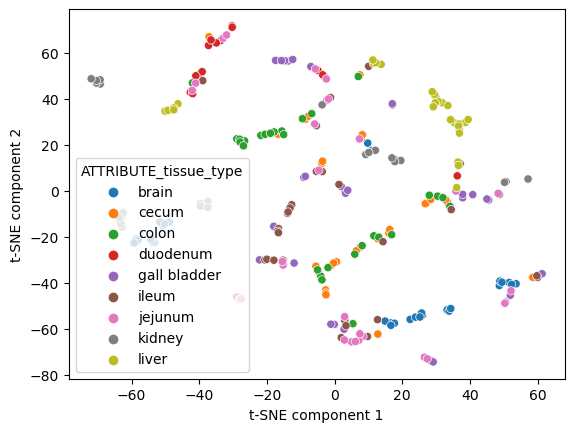

In [83]:
%matplotlib inline

import seaborn as sns
sns.scatterplot(data=tdf, x="t-SNE component 1", y="t-SNE component 2", hue="ATTRIBUTE_tissue_type")

In [88]:
dm1 = squareform(pdist(df2, metric='canberra'))
dm1 = skbio.DistanceMatrix(dm1, ids=df2.index.tolist())
#dm1 = Artifact.import_data("DistanceMatrix", dm1)
dm1.data

array([[   0.        ,  749.48250294,  796.64333756, ..., 1334.14243656,
        1446.85217607, 1382.29054437],
       [ 749.48250294,    0.        ,  579.10320393, ..., 1286.33670019,
        1352.33763432, 1303.61897435],
       [ 796.64333756,  579.10320393,    0.        , ..., 1338.50811404,
        1440.73026002, 1365.8644493 ],
       ...,
       [1334.14243656, 1286.33670019, 1338.50811404, ...,    0.        ,
         996.1643527 , 1141.91613273],
       [1446.85217607, 1352.33763432, 1440.73026002, ...,  996.1643527 ,
           0.        ,  901.37132653],
       [1382.29054437, 1303.61897435, 1365.8644493 , ..., 1141.91613273,
         901.37132653,    0.        ]])

In [95]:
# 1. Assume you have your distance matrix 'dissimilarity_matrix' (n_samples x n_samples)
# 2. Initialize t-SNE with metric='precomputed'
tsne = TSNE(n_components=2, metric='precomputed', init='random', perplexity=30, random_state=42)

# 3. Fit and transform
X_embedded = tsne.fit_transform(dm1.data)

/opt/conda/envs/qiime2-2023.7/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:691: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  warnings.warn(


In [96]:
tdf = pd.DataFrame(X_embedded)
tdf.columns = ['t-SNE component 1', 't-SNE component 2']
tdf.head()

,t-SNE component 1,t-SNE component 2
0,3.620618,-5.250891
1,7.379841,-3.845107
2,6.967738,-2.380238
3,7.706278,-5.137109
4,6.784708,-6.421918


In [97]:
tdf.shape

(248, 2)

In [98]:
tdf['ATTRIBUTE_tissue_type'] = meta['ATTRIBUTE_tissue_type'].tolist()

<AxesSubplot: xlabel='t-SNE component 1', ylabel='t-SNE component 2'>

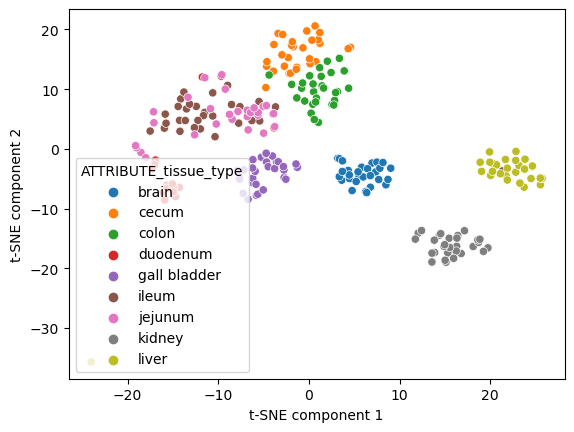

In [99]:
sns.scatterplot(data=tdf, x="t-SNE component 1", y="t-SNE component 2", hue="ATTRIBUTE_tissue_type")

/opt/conda/envs/qiime2-2023.7/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:691: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  warnings.warn(


<AxesSubplot: xlabel='t-SNE component 1', ylabel='t-SNE component 2'>

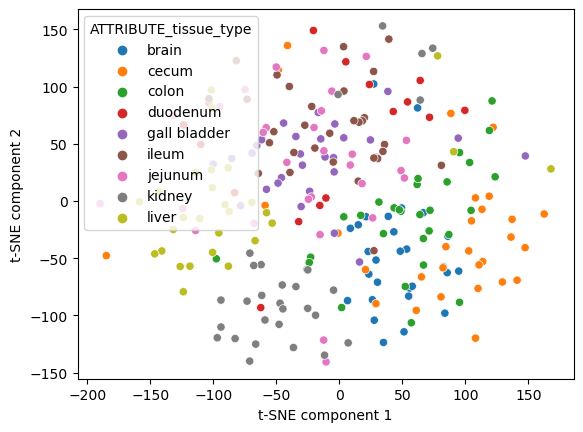

In [94]:
#https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf
#https://www.cs.toronto.edu/~jlucas/teaching/csc411/lectures/lec13_handout.pdf
#https://library.qiime2.org/plugins/qiime2/q2-diversity/overview#q2-action-diversity-tsne
tsne = TSNE(n_components=3, metric='precomputed', init='random', perplexity=30, random_state=42)

# 3. Fit and transform
X_embedded = tsne.fit_transform(dm1.data)

tdf = pd.DataFrame(X_embedded[:,[0,1]])
tdf.columns = ['t-SNE component 1', 't-SNE component 2']
tdf['ATTRIBUTE_tissue_type'] = meta['ATTRIBUTE_tissue_type'].tolist()
sns.scatterplot(data=tdf, x="t-SNE component 1", y="t-SNE component 2", hue="ATTRIBUTE_tissue_type")

In [107]:
!pip install umap-learn

In [108]:
# Initialize UMAP model (n_components=2 for visualization)
# The random_state parameter ensures reproducibility
import umap
reducer = umap.UMAP(n_components=2, random_state=42)

# Fit and transform the data
embedding = reducer.fit_transform(df2)

# You can also transform new data with the trained model
# new_data_embedding = reducer.transform(new_data)

In [109]:
embedding.shape

(248, 2)

In [111]:
embedding

array([[ 9.323275  ,  1.3279587 ],
       [ 9.282077  ,  1.3028841 ],
       [ 9.19337   ,  1.7557408 ],
       [ 8.871387  ,  5.264088  ],
       [ 8.93187   ,  5.4872003 ],
       [ 8.768435  ,  5.714673  ],
       [ 6.743579  ,  6.7302012 ],
       [ 9.015522  ,  5.070329  ],
       [ 9.582466  ,  1.2013109 ],
       [ 9.188345  ,  1.6617986 ],
       [10.430343  ,  1.1457214 ],
       [10.419193  ,  0.95145327],
       [ 8.169206  ,  5.97277   ],
       [ 8.896872  ,  5.6288667 ],
       [10.27149   ,  1.132753  ],
       [ 9.077262  ,  1.964269  ],
       [10.214804  ,  1.0905887 ],
       [ 1.1999589 ,  7.797702  ],
       [ 8.256628  ,  6.066318  ],
       [ 9.353048  ,  1.3944799 ],
       [ 9.326607  ,  1.484488  ],
       [ 9.536039  ,  1.5002089 ],
       [10.089578  ,  1.1069716 ],
       [10.226406  ,  1.1495615 ],
       [ 9.225892  ,  1.706718  ],
       [ 9.431294  ,  1.3030014 ],
       [ 9.416924  ,  1.3876079 ],
       [ 8.925916  ,  5.621379  ],
       [ 8.912606  ,

<AxesSubplot: xlabel='UMAP component 1', ylabel='UMAP component 2'>

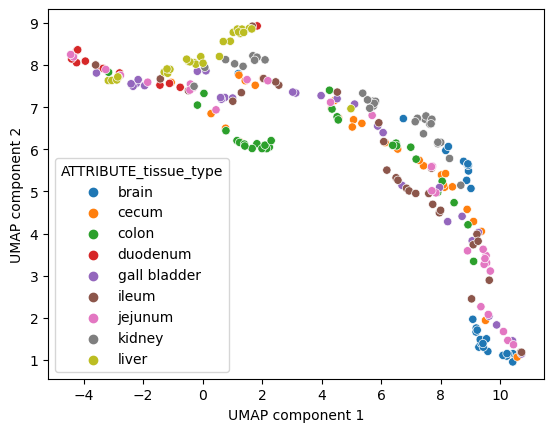

In [114]:
tdf = pd.DataFrame(embedding[:,[0,1]])
tdf.columns = ['UMAP component 1', 'UMAP component 2']
tdf['ATTRIBUTE_tissue_type'] = meta['ATTRIBUTE_tissue_type'].tolist()
sns.scatterplot(data=tdf, x="UMAP component 1", y="UMAP component 2", hue="ATTRIBUTE_tissue_type")

/opt/conda/envs/qiime2-2023.7/lib/python3.8/site-packages/umap/umap_.py:1780: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


<AxesSubplot: xlabel='UMAP component 1', ylabel='UMAP component 2'>

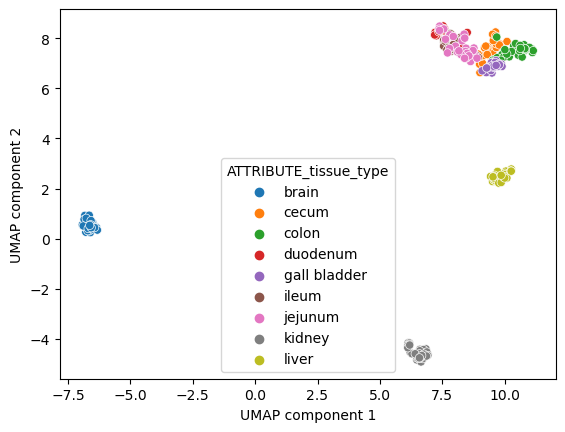

In [115]:
reducer = umap.UMAP(n_components=3, random_state=42, metric='precomputed')

# Fit and transform the data
embedding = reducer.fit_transform(dm1.data)

tdf = pd.DataFrame(embedding[:,[0,1]])
tdf.columns = ['UMAP component 1', 'UMAP component 2']
tdf['ATTRIBUTE_tissue_type'] = meta['ATTRIBUTE_tissue_type'].tolist()
sns.scatterplot(data=tdf, x="UMAP component 1", y="UMAP component 2", hue="ATTRIBUTE_tissue_type")

In [116]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, y = make_blobs(random_state=42)

kmeans = KMeans(n_clusters=2, random_state=42)

silhouette_score(X, kmeans.fit_predict(X))

0.7020937832636733

In [119]:
silhouette_score(X, y)

0.8469881221532085

In [118]:
y

array([2, 1, 0, 1, 2, 1, 0, 1, 1, 0, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 2,
       2, 0, 0, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 0, 0, 0, 1, 1, 2, 0, 1, 0,
       0, 1, 2, 2, 2, 1, 1, 1, 0, 2, 2, 2, 0, 0, 1, 0, 2, 1, 2, 1, 2, 2,
       1, 2, 1, 1, 1, 2, 2, 0, 1, 2, 1, 2, 1, 1, 0, 1, 0, 2, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 2, 0])

In [117]:
X

array([[-7.72642091, -8.39495682],
       [ 5.45339605,  0.74230537],
       [-2.97867201,  9.55684617],
       [ 6.04267315,  0.57131862],
       [-6.52183983, -6.31932507],
       [ 3.64934251,  1.40687195],
       [-2.17793419,  9.98983126],
       [ 4.42020695,  2.33028226],
       [ 4.73695639,  2.94181467],
       [-3.6601912 ,  9.38998415],
       [-3.05358035,  9.12520872],
       [-6.65216726, -5.57296684],
       [-6.35768563, -6.58312492],
       [-3.6155326 ,  7.8180795 ],
       [-1.77073104,  9.18565441],
       [-7.95051969, -6.39763718],
       [-6.60293639, -6.05292634],
       [-2.58120774, 10.01781903],
       [-7.76348463, -6.72638449],
       [-6.40638957, -6.95293851],
       [-2.97261532,  8.54855637],
       [-6.9567289 , -6.53895762],
       [-7.32614214, -6.0237108 ],
       [-2.14780202, 10.55232269],
       [-2.54502366, 10.57892978],
       [-2.96983639, 10.07140835],
       [ 3.22450809,  1.55252436],
       [-6.25395984, -7.73726715],
       [-7.85430886,

In [146]:
from sklearn.cluster import AgglomerativeClustering

dissimilarities = [
    "canberra",
    "braycurtis",
    "euclidean",
    "seuclidean",
    "cityblock",
    "chebyshev",
    "wminkowski",
    "correlation",
    "cosine",
    "dice",
    "hamming",
    "jaccard",
    "kulsinski",
    "mahalanobis",
    "matching",
    "rogerstanimoto",
    "russellrao",
    "sokalmichener",
    "sokalsneath",
    "yule"
]

silhouete_avg = {}
silhouete_avg_agl = {}

for d in dissimilarities:
    try:
        dm1 = squareform(pdist(df2, metric=d))
        dm1 = skbio.DistanceMatrix(dm1, ids=df2.index.tolist())

        silhouete_avg[d] = silhouette_score(dm1.data, meta['ATTRIBUTE_tissue_type'].tolist(),
                                             metric = "precomputed")
        n = len(meta['ATTRIBUTE_tissue_type'].unique())
        model = AgglomerativeClustering(n_clusters=n, linkage='average', affinity='precomputed')
        model.fit(dm1.data)
        silhouete_avg_agl[d] = silhouette_score(dm1.data, model.labels_,
                                             metric = "precomputed")

        #n = len(meta['ATTRIBUTE_tissue_type'].unique())
        #kmeans = KMeans(n_clusters=n, random_state=42)
    except Exception:    
        print(f'Failed for dissimilarity {d}')
        continue

Failed for dissimilarity seuclidean
Failed for dissimilarity wminkowski
Failed for dissimilarity mahalanobis


In [149]:
silhouete_avg_agl

{'canberra': 0.369682575849936,
 'braycurtis': 0.13871179333749503,
 'euclidean': 0.49146736388580703,
 'cityblock': 0.48468970140690476,
 'chebyshev': 0.528125349600041,
 'correlation': 0.26159927858575915,
 'cosine': 0.26158205362741715,
 'dice': 0.20701817731914482,
 'hamming': 0.39867945678053474,
 'jaccard': 9.735356408121617e-09,
 'kulsinski': 0.017005621906964863,
 'matching': 0.39867945678053474,
 'rogerstanimoto': 0.31087041622886774,
 'russellrao': 0.016443578403566843,
 'sokalmichener': 0.31087041622886774,
 'sokalsneath': 0.09726299689039256,
 'yule': 0.44867780380245864}

In [150]:
silhouete_avg

{'canberra': 0.1071271990884701,
 'braycurtis': 0.10778043541957937,
 'euclidean': -0.15284326389244512,
 'cityblock': 0.027198362930107134,
 'chebyshev': -0.21228498274970956,
 'correlation': 0.10965055638022912,
 'cosine': 0.10966257894141339,
 'dice': 0.18376432328184875,
 'hamming': -0.03483652191994784,
 'jaccard': 1.5511667876600214e-07,
 'kulsinski': 0.010662563648584047,
 'matching': -0.03483652191994784,
 'rogerstanimoto': 0.14657769377194632,
 'russellrao': 0.009971832190204212,
 'sokalmichener': 0.14657769377194632,
 'sokalsneath': 0.08614073832951337,
 'yule': 0.38587650641474197}